# Kernels & Linear Classifiers — Visual Guide

We'll build intuition from scratch:
1. What is a linear classifier?
2. When do linear classifiers fail?
3. Feature maps — lifting data to higher dimensions
4. The kernel trick
5. RBF kernel in action
6. SVM with and without kernels

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_circles, make_moons, make_blobs
from sklearn.preprocessing import StandardScaler

# consistent style
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#eee',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'text.color':       '#eee',
    'grid.color':       '#333',
    'grid.linestyle':   '--',
    'font.family':      'monospace',
})

C1, C2 = '#e94560', '#0f3460'  # class colors
ACC     = '#16213e'             # accent
print('Libraries loaded.')

Libraries loaded.


---
## 1 — What is a Linear Classifier?

A **linear classifier** finds a hyperplane (line in 2D, plane in 3D, …) that separates two classes.

$$f(x) = w \cdot x + b$$

- If $f(x) > 0$ → class +1  
- If $f(x) < 0$ → class −1  

The **decision boundary** is where $f(x) = 0$.

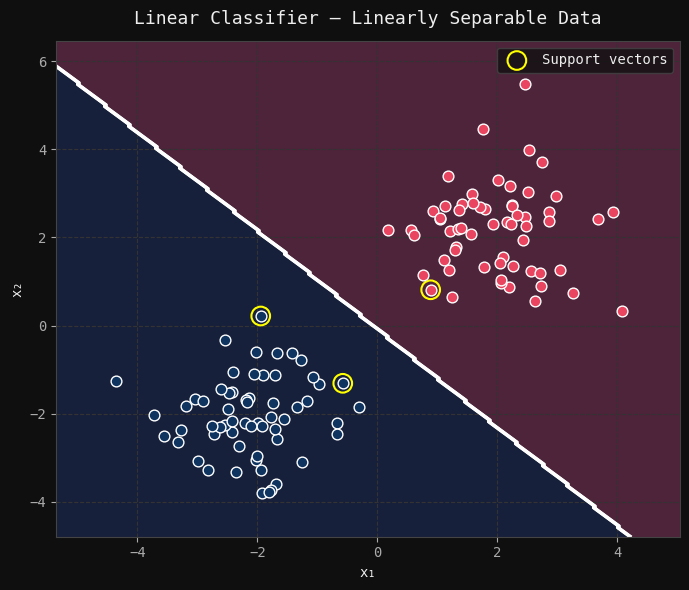

White line = decision boundary  |  Yellow circles = support vectors


In [2]:
np.random.seed(42)
X_lin, y_lin = make_blobs(n_samples=120, centers=[[-2, -2], [2, 2]], cluster_std=0.9)

clf_lin = SVC(kernel='linear', C=1.0)
clf_lin.fit(X_lin, y_lin)

# build mesh for decision region
def make_mesh(X, h=0.05, pad=1.0):
    x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    return xx, yy

fig, ax = plt.subplots(figsize=(7, 6))

xx, yy = make_mesh(X_lin)
Z = clf_lin.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contourf(xx, yy, Z, alpha=0.25, cmap=ListedColormap([C2, C1]))
ax.contour(xx, yy, Z, colors='white', linewidths=1.5)

# support vectors
ax.scatter(clf_lin.support_vectors_[:, 0],
           clf_lin.support_vectors_[:, 1],
           s=180, facecolors='none', edgecolors='yellow',
           linewidths=1.5, zorder=3, label='Support vectors')

# data points
ax.scatter(X_lin[y_lin==0, 0], X_lin[y_lin==0, 1], c=C2, edgecolors='white', s=60, zorder=4)
ax.scatter(X_lin[y_lin==1, 0], X_lin[y_lin==1, 1], c=C1, edgecolors='white', s=60, zorder=4)

ax.set_title('Linear Classifier — Linearly Separable Data', fontsize=13, pad=12)
ax.set_xlabel('x₁');  ax.set_ylabel('x₂')
ax.legend(facecolor='#111', edgecolor='#444')
ax.grid(True)
plt.tight_layout()
plt.savefig('01_linear_classifier.png', dpi=150, bbox_inches='tight')
plt.show()
print('White line = decision boundary  |  Yellow circles = support vectors')

---
## 2 — When Linear Classifiers Fail

Real data is rarely linearly separable.  
Two classic examples: **concentric circles** and **moons**.

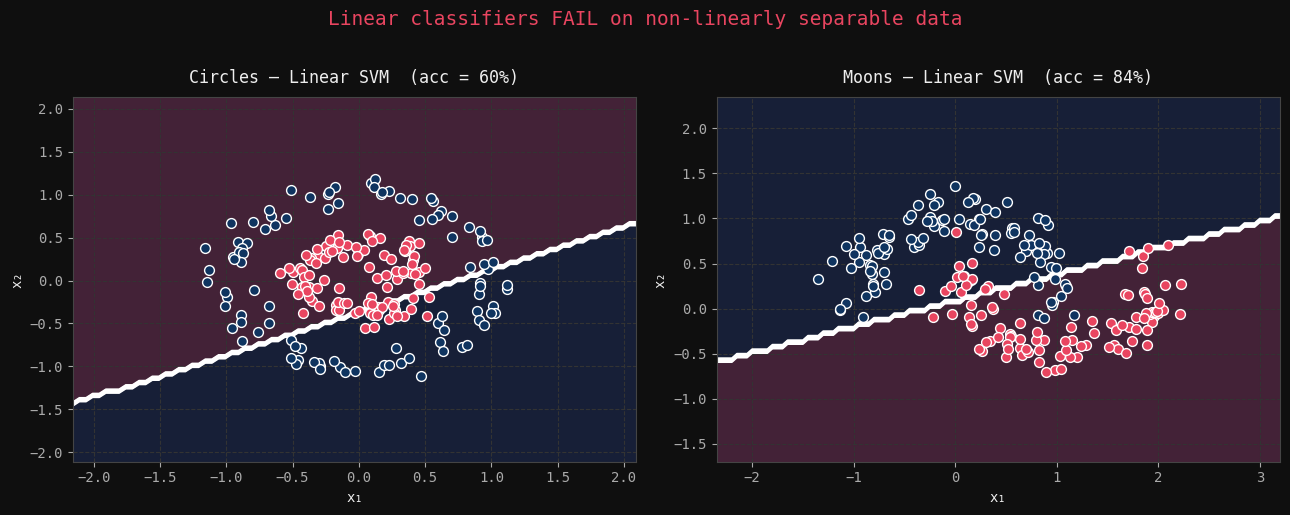

In [3]:
X_circ, y_circ = make_circles(n_samples=200, noise=0.1, factor=0.4, random_state=42)
X_moon, y_moon = make_moons(n_samples=200, noise=0.15, random_state=42)

datasets = [
    (X_circ, y_circ, 'Circles'),
    (X_moon, y_moon, 'Moons'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (X, y, title) in zip(axes, datasets):
    clf = SVC(kernel='linear', C=1.0)
    clf.fit(X, y)

    xx, yy = make_mesh(X)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.20, cmap=ListedColormap([C2, C1]))
    ax.contour(xx, yy, Z, colors='white', linewidths=1.2)

    ax.scatter(X[y==0, 0], X[y==0, 1], c=C2, edgecolors='white', s=50, zorder=4)
    ax.scatter(X[y==1, 0], X[y==1, 1], c=C1, edgecolors='white', s=50, zorder=4)

    # accuracy
    acc = clf.score(X, y)
    ax.set_title(f'{title} — Linear SVM  (acc = {acc:.0%})', fontsize=12, pad=10)
    ax.set_xlabel('x₁');  ax.set_ylabel('x₂')
    ax.grid(True)

fig.suptitle('Linear classifiers FAIL on non-linearly separable data', 
             fontsize=14, y=1.02, color='#e94560')
plt.tight_layout()
plt.savefig('02_linear_fails.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3 — Feature Maps: Lifting Data to Higher Dimensions

**Idea:** transform each point $x = (x_1, x_2)$ into a new space where the classes *are* linearly separable.

For the circles problem, a natural map is:

$$\phi(x_1, x_2) = (x_1,\ x_2,\ x_1^2 + x_2^2)$$

The third dimension is just the **radius squared**. In 3D the two rings sit at different heights — now a flat plane separates them.

/Users/andersonchen/machine-learning-visuals/.venv/lib/python3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Users/andersonchen/machine-learning-visuals/.venv/lib/python3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))


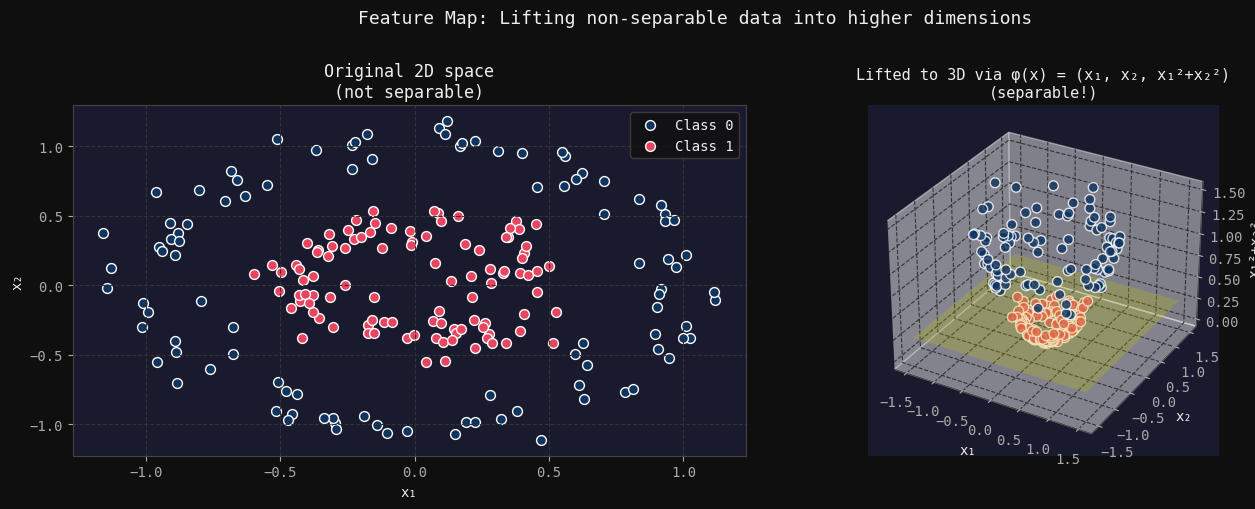

Yellow plane = linear separator in 3D  →  becomes a circle in 2D


In [4]:
from mpl_toolkits.mplot3d import Axes3D  # noqa

X, y = X_circ, y_circ

# feature map: add radius-squared as 3rd dimension
r2 = X[:, 0]**2 + X[:, 1]**2
X3d = np.column_stack([X, r2])

fig = plt.figure(figsize=(14, 5))

# --- left: original 2D ---
ax1 = fig.add_subplot(121)
ax1.scatter(X[y==0, 0], X[y==0, 1], c=C2, edgecolors='white', s=50, label='Class 0')
ax1.scatter(X[y==1, 0], X[y==1, 1], c=C1, edgecolors='white', s=50, label='Class 1')
ax1.set_title('Original 2D space\n(not separable)', fontsize=12)
ax1.set_xlabel('x₁');  ax1.set_ylabel('x₂')
ax1.legend(facecolor='#111', edgecolor='#444')
ax1.grid(True)

# --- right: lifted 3D ---
ax2 = fig.add_subplot(122, projection='3d')
ax2.set_facecolor('#1a1a2e')
ax2.scatter(X3d[y==0, 0], X3d[y==0, 1], X3d[y==0, 2],
            c=C2, edgecolors='white', s=50, alpha=0.8)
ax2.scatter(X3d[y==1, 0], X3d[y==1, 1], X3d[y==1, 2],
            c=C1, edgecolors='white', s=50, alpha=0.8)

# separating plane at r² ≈ 0.25 (midpoint between inner/outer ring)
xx_p, yy_p = np.meshgrid(np.linspace(-1.5, 1.5, 20), np.linspace(-1.5, 1.5, 20))
zz_p = np.full_like(xx_p, 0.25)
ax2.plot_surface(xx_p, yy_p, zz_p, alpha=0.25, color='yellow')

ax2.set_title('Lifted to 3D via φ(x) = (x₁, x₂, x₁²+x₂²)\n(separable!)', fontsize=11)
ax2.set_xlabel('x₁');  ax2.set_ylabel('x₂');  ax2.set_zlabel('x₁²+x₂²')
ax2.tick_params(colors='#aaa')

fig.suptitle('Feature Map: Lifting non-separable data into higher dimensions', 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('03_feature_map_3d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Yellow plane = linear separator in 3D  →  becomes a circle in 2D')

---
## 4 — The Kernel Trick

Computing $\phi(x)$ explicitly is expensive (especially for infinite-dimensional maps).  
The key insight: algorithms only need **dot products** $\phi(x) \cdot \phi(x')$.

A **kernel function** computes this dot product directly:

| Kernel | $K(x, x')$ | Maps to |
|---|---|---|
| Linear | $x \cdot x'$ | Same space |
| Polynomial deg-2 | $(x \cdot x' + 1)^2$ | Degree-2 features |
| RBF / Gaussian | $\exp(-\gamma \|x - x'\|^2)$ | Infinite dimensions |

Below we visualise the **kernel matrix** — each cell $(i,j)$ is how similar point $i$ is to point $j$.

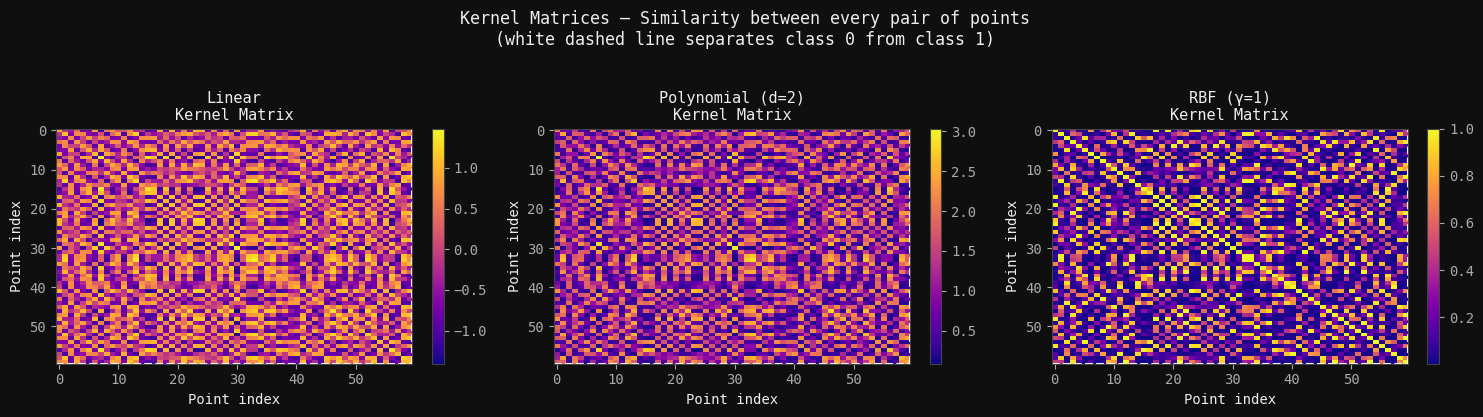

In [5]:
from sklearn.metrics.pairwise import rbf_kernel, polynomial_kernel, linear_kernel

# use a small subset for clarity
idx = np.argsort(y)  # sort by class so the block structure is obvious
Xs = X[idx[:60]]
ys = y[idx[:60]]

kernels = {
    'Linear': linear_kernel(Xs),
    'Polynomial (d=2)': polynomial_kernel(Xs, degree=2, coef0=1),
    'RBF (γ=1)': rbf_kernel(Xs, gamma=1.0),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, K) in zip(axes, kernels.items()):
    im = ax.imshow(K, cmap='plasma', aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(f'{name}\nKernel Matrix', fontsize=11)
    ax.set_xlabel('Point index');  ax.set_ylabel('Point index')
    # class boundary line
    n0 = np.sum(ys == 0)
    for pos in [n0 - 0.5]:
        ax.axhline(pos, color='white', linewidth=1.5, linestyle='--')
        ax.axvline(pos, color='white', linewidth=1.5, linestyle='--')

fig.suptitle('Kernel Matrices — Similarity between every pair of points\n'
             '(white dashed line separates class 0 from class 1)', 
             fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig('04_kernel_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5 — RBF Kernel: Effect of γ

$K(x, x') = \exp(-\gamma \|x - x'\|^2)$

- **Small γ** → wide bell → distant points still influence each other → smooth boundary  
- **Large γ** → narrow bell → only very close points matter → wiggly boundary (overfitting)

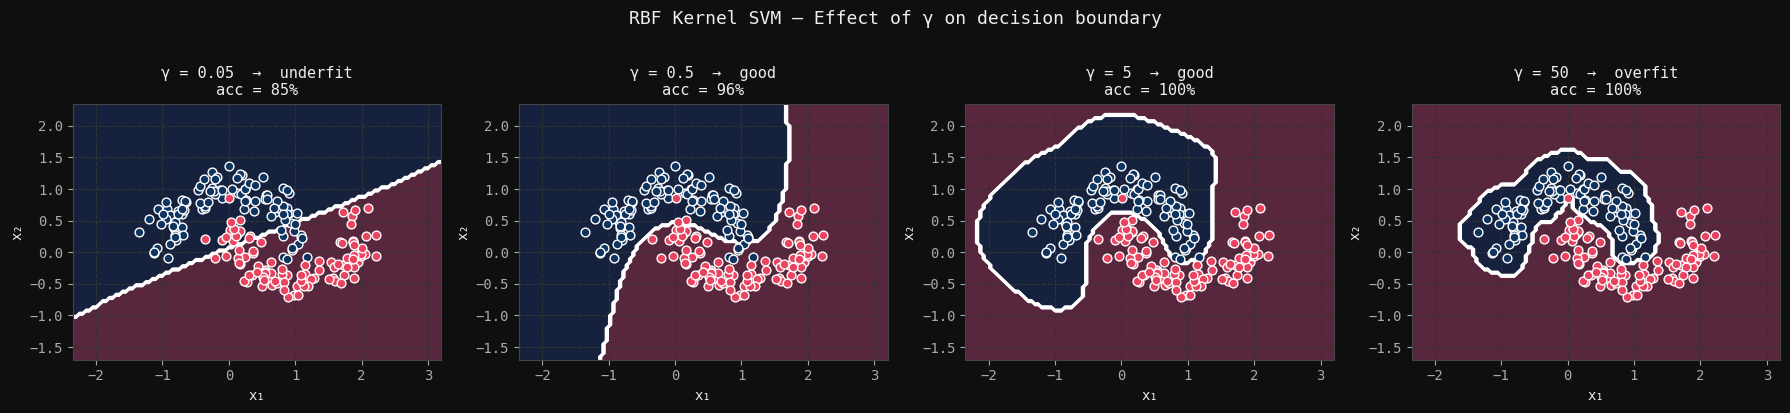

In [6]:
gammas = [0.05, 0.5, 5, 50]
X, y   = X_moon, y_moon

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, g in zip(axes, gammas):
    clf = SVC(kernel='rbf', gamma=g, C=1.0)
    clf.fit(X, y)

    xx, yy = make_mesh(X)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.30, cmap=ListedColormap([C2, C1]))
    ax.contour(xx, yy, Z, colors='white', linewidths=1.0)

    ax.scatter(X[y==0, 0], X[y==0, 1], c=C2, edgecolors='white', s=40, zorder=4)
    ax.scatter(X[y==1, 0], X[y==1, 1], c=C1, edgecolors='white', s=40, zorder=4)

    acc = clf.score(X, y)
    label = 'underfit' if g == gammas[0] else ('overfit' if g == gammas[-1] else 'good')
    ax.set_title(f'γ = {g}  →  {label}\nacc = {acc:.0%}', fontsize=11)
    ax.set_xlabel('x₁');  ax.set_ylabel('x₂')
    ax.grid(True)

fig.suptitle('RBF Kernel SVM — Effect of γ on decision boundary', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('05_rbf_gamma.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6 — Side-by-Side: Linear vs Kernel SVM

Same dataset, same algorithm (SVM) — only the kernel changes.

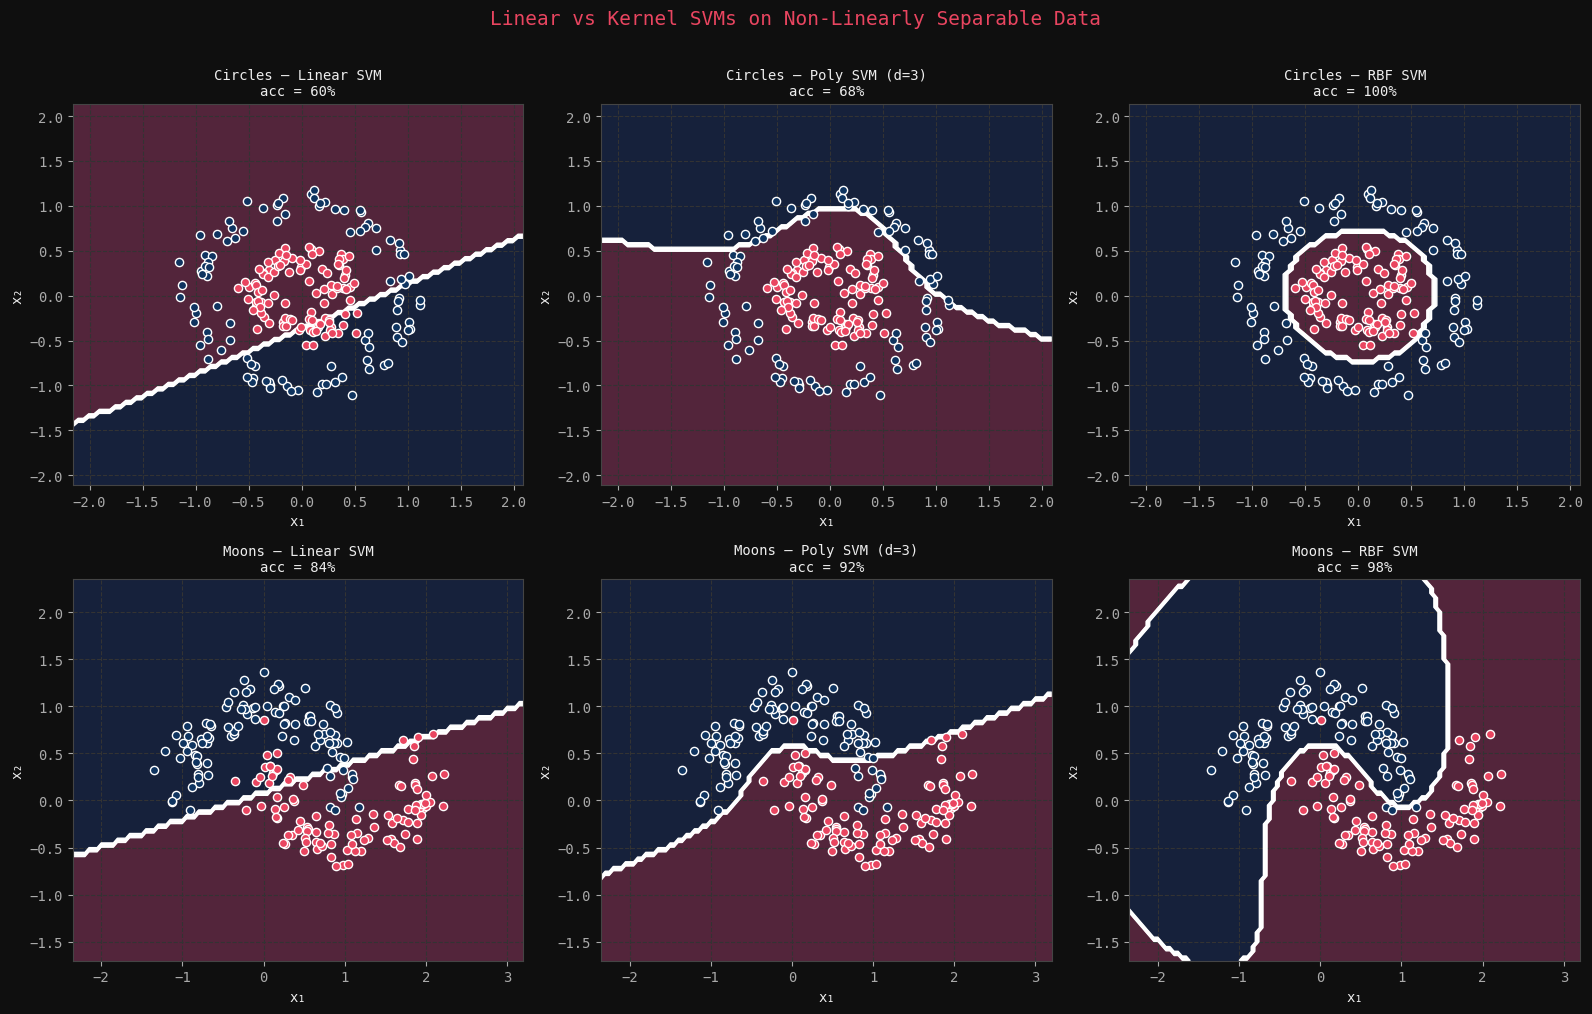

In [7]:
datasets = [
    (make_circles(n_samples=200, noise=0.1, factor=0.4, random_state=42), 'Circles'),
    (make_moons(n_samples=200, noise=0.15, random_state=42),              'Moons'),
]
clfs = [
    (SVC(kernel='linear', C=1.0),     'Linear SVM'),
    (SVC(kernel='poly',   degree=3),  'Poly SVM (d=3)'),
    (SVC(kernel='rbf',    gamma=1.0), 'RBF SVM'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for row, ((X, y), dname) in enumerate(datasets):
    for col, (clf, cname) in enumerate(clfs):
        ax = axes[row, col]
        clf.fit(X, y)

        xx, yy = make_mesh(X)
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        ax.contourf(xx, yy, Z, alpha=0.28, cmap=ListedColormap([C2, C1]))
        ax.contour(xx, yy, Z, colors='white', linewidths=1.0)

        ax.scatter(X[y==0, 0], X[y==0, 1], c=C2, edgecolors='white', s=35, zorder=4)
        ax.scatter(X[y==1, 0], X[y==1, 1], c=C1, edgecolors='white', s=35, zorder=4)

        acc = clf.score(X, y)
        ax.set_title(f'{dname} — {cname}\nacc = {acc:.0%}', fontsize=10)
        ax.set_xlabel('x₁');  ax.set_ylabel('x₂')
        ax.grid(True)

fig.suptitle('Linear vs Kernel SVMs on Non-Linearly Separable Data', 
             fontsize=14, y=1.01, color='#e94560')
plt.tight_layout()
plt.savefig('06_linear_vs_kernel.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7 — The RBF Kernel Bell Curve (1D intuition)

For a fixed reference point $x'$, the RBF kernel $K(x, x') = \exp(-\gamma(x - x')^2)$  
is just a Gaussian bell centred at $x'$.

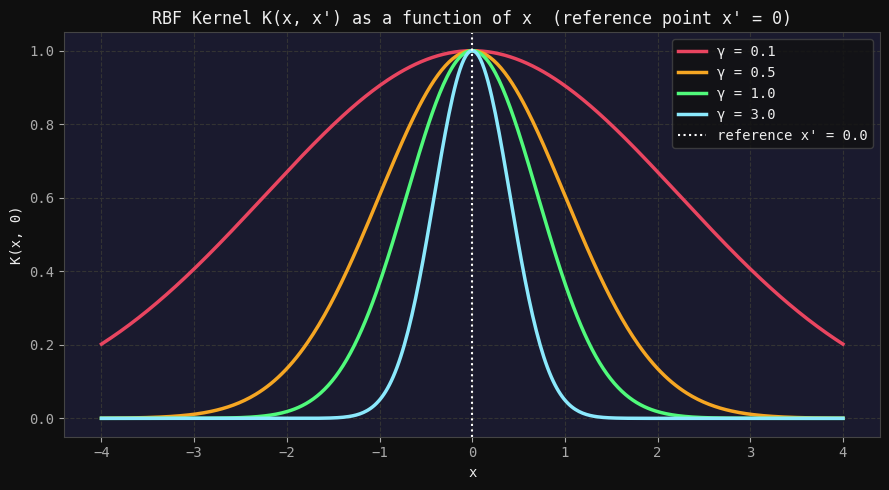

Higher γ = narrower bell = only nearby points matter


In [8]:
x      = np.linspace(-4, 4, 400)
x_ref  = 0.0
gammas = [0.1, 0.5, 1.0, 3.0]
colors = ['#e94560', '#f5a623', '#50fa7b', '#8be9fd']

fig, ax = plt.subplots(figsize=(9, 5))

for g, col in zip(gammas, colors):
    K = np.exp(-g * (x - x_ref)**2)
    ax.plot(x, K, color=col, linewidth=2.5, label=f'γ = {g}')

ax.axvline(x_ref, color='white', linestyle=':', linewidth=1.5, label=f'reference x\' = {x_ref}')
ax.set_title('RBF Kernel K(x, x\') as a function of x  (reference point x\' = 0)', fontsize=12)
ax.set_xlabel('x');  ax.set_ylabel('K(x, 0)')
ax.legend(facecolor='#111', edgecolor='#444')
ax.grid(True)
plt.tight_layout()
plt.savefig('07_rbf_bell_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Higher γ = narrower bell = only nearby points matter')

---
## Summary

| Concept | One-line |
|---|---|
| **Linear classifier** | Separates classes with a hyperplane: $w \cdot x + b = 0$ |
| **Feature map φ** | Lifts data to higher dims where it becomes linearly separable |
| **Kernel trick** | Computes $\phi(x)\cdot\phi(x')$ cheaply without computing $\phi$ explicitly |
| **RBF kernel** | $\exp(-\gamma\|x-x'\|^2)$ — infinite-dimensional, controlled by γ |
| **Small γ** | Smooth boundary, may underfit |
| **Large γ** | Wiggly boundary, may overfit |

**Next step:** read Chapter 6 ("Kernel Methods") of *Pattern Recognition and Machine Learning* — Bishop.